In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import kagglehub

In [3]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

print("Experiment: ResNet50 with Focal Loss")
print("Focal-loss alpha: 0.29")
print("Focal-loss gamma: 2.0")
print("Dropout rate: Disabled")
print("Balanced batches: Disabled")
print("Class weights: Disabled")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Experiment: ResNet50 with Focal Loss
Focal-loss alpha: 0.29
Focal-loss gamma: 2.0
Dropout rate: Disabled
Balanced batches: Disabled
Class weights: Disabled


In [4]:
dataset_path = kagglehub.dataset_download(
    "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
)

image_root = Path(dataset_path) / "combined_images"

print("Dataset path:", dataset_path)
print("Image folder:", image_root)
print("Image folder exists:", image_root.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [5]:
class_mapping = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, binary_label in class_mapping.items():
    class_folder = image_root / class_name

    for file_path in sorted(class_folder.iterdir()):
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(file_path),
                "original_class": class_name,
                "label": binary_label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df), "images")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df), "images")
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df), "images")
print(test_df["label"].value_counts().sort_index())

Training: 30800 images
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600 images
label
0    1920
1    4680
Name: count, dtype: int64


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_original_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, tf.cast(label, tf.float32)

def create_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].values,
        dataframe["label"].values
    ))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_original_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    return dataset.prefetch(AUTOTUNE)

train_dataset = create_dataset(train_df, training=True)
validation_dataset = create_dataset(validation_df)
test_dataset = create_dataset(test_df)

print("Natural training batches created.")
print("Balanced batches: False")

I0000 00:00:1789373835.580887      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Natural training batches created.
Balanced batches: False


In [8]:
image_batch, label_batch = next(iter(train_dataset))

print("Image batch shape:", image_batch.shape)
print("Label batch shape:", label_batch.shape)
print(
    "Pixel range:",
    float(tf.reduce_min(image_batch)),
    "to",
    float(tf.reduce_max(image_batch))
)

print("NonDemented in first batch:",
      int(tf.reduce_sum(tf.cast(label_batch == 0, tf.int32))))

print("Demented in first batch:",
      int(tf.reduce_sum(tf.cast(label_batch == 1, tf.int32))))

print("First labels:", label_batch[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0
NonDemented in first batch: 12
Demented in first batch: 20
First labels: [0. 1. 0. 0. 1. 1. 0. 1. 0. 1.]


In [9]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 0.0001

FOCAL_ALPHA = 0.29
FOCAL_GAMMA = 2.0

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Focal alpha:", FOCAL_ALPHA)
print("Focal gamma:", FOCAL_GAMMA)

print("Preprocessing: Original images")
print("Data augmentation: Disabled")
print("Dropout rate: Disabled")
print("Natural training batches: Enabled")
print("Balanced batches: Disabled")
print("Class weights: Disabled")

Image size: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001
Focal alpha: 0.29
Focal gamma: 2.0
Preprocessing: Original images
Data augmentation: Disabled
Dropout rate: Disabled
Natural training batches: Enabled
Balanced batches: Disabled
Class weights: Disabled


In [10]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))

x = tf.keras.applications.resnet50.preprocess_input(inputs)

base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Dropout intentionally removed
outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="ResNet50_FocalLoss_NoDropout"
)

focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=True,
    alpha=FOCAL_ALPHA,
    gamma=FOCAL_GAMMA,
    from_logits=False
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=focal_loss,
    metrics=["accuracy"]
)

print("Total parameters:", model.count_params())
print(
    "Trainable parameters:",
    sum(tf.keras.backend.count_params(weight)
        for weight in model.trainable_weights)
)
print("ResNet50 frozen:", not base_model.trainable)
print("Loss: Binary Focal Cross-Entropy")
print("Dropout enabled: False")

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
Loss: Binary Focal Cross-Entropy
Dropout enabled: False


Model: "ResNet50_FocalLoss_NoDropout"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer[0][0] │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/resnet50_focal_no_dropout_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks created.")

Callbacks created.


In [12]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
  3/963 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.8281 - loss: 0.1016   

I0000 00:00:1789373934.075849     158 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6063 - loss: 0.0757
Epoch 1: val_loss improved from None to 0.05484, saving model to /kaggle/working/resnet50_focal_no_dropout_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_focal_no_dropout_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 74s 65ms/step - accuracy: 0.6822 - loss: 0.0638 - val_accuracy: 0.7150 - val_loss: 0.0548 - learning_rate: 1.0000e-04
Epoch 2/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7596 - loss: 0.0523
Epoch 2: val_loss improved from 0.05484 to 0.04940, saving model to /kaggle/working/resnet50_focal_no_dropout_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_focal_no_dropout_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 52s 53ms/step - accuracy: 0.7651 - loss: 0.0516 - val_accuracy: 0.7865 - val_loss: 0.0494 - learning_rate: 1.0000e-04
Epoch 3/30
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7767 - loss: 0.0491
Epoch 3: val_loss improved from 0.04940 t

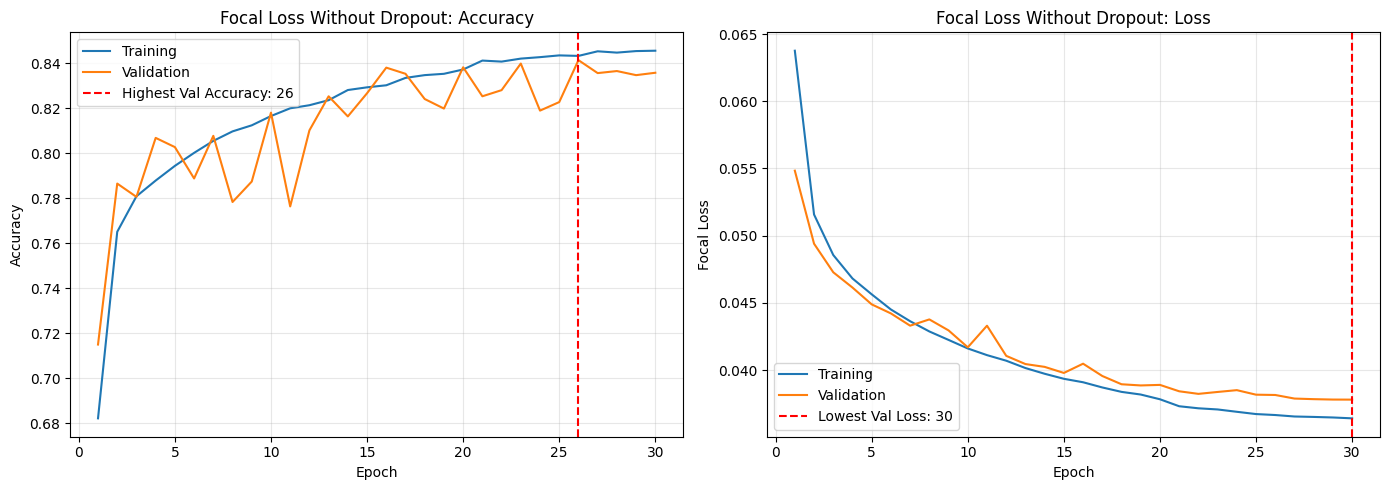

Best validation-loss epoch: 30
Best validation-accuracy epoch: 26


In [13]:
best_loss_epoch = np.argmin(history.history["val_loss"]) + 1
best_accuracy_epoch = np.argmax(history.history["val_accuracy"]) + 1
epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].axvline(
    best_accuracy_epoch,
    color="red",
    linestyle="--",
    label=f"Highest Val Accuracy: {best_accuracy_epoch}"
)
axes[0].set_title("Focal Loss Without Dropout: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].axvline(
    best_loss_epoch,
    color="red",
    linestyle="--",
    label=f"Lowest Val Loss: {best_loss_epoch}"
)
axes[1].set_title("Focal Loss Without Dropout: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Focal Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Best validation-loss epoch:", best_loss_epoch)
print("Best validation-accuracy epoch:", best_accuracy_epoch)

In [14]:
best_model = tf.keras.models.load_model(
    "/kaggle/working/resnet50_focal_no_dropout_best.keras"
)

print("Best focal-loss no-dropout model loaded.")
print("Selected validation-loss epoch:", best_loss_epoch)

Best focal-loss no-dropout model loaded.
Selected validation-loss epoch: 30


In [15]:
test_loss, test_accuracy = best_model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Focal Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8317 - loss: 0.0389
Test Focal Loss: 0.0389
Test Accuracy: 0.8317


In [16]:
test_probabilities = best_model.predict(
    test_dataset,
    verbose=1
).ravel()

test_predictions = (test_probabilities >= 0.5).astype(int)
true_labels = test_df["label"].to_numpy()

print("Test images:", len(true_labels))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))
print("First probabilities:", np.round(test_probabilities[:10], 4))
print("First predictions:", test_predictions[:10])

207/207 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600
First probabilities: [0.7181 0.7034 0.6395 0.5627 0.7503 0.7325 0.7092 0.5516 0.9135 0.7322]
First predictions: [1 1 1 1 1 1 1 1 1 1]


In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(
    true_labels, test_predictions
).ravel()

specificity = tn / (tn + fp)

print("Test Focal Loss:", round(test_loss, 4))
print("Accuracy:", round(
    accuracy_score(true_labels, test_predictions), 4
))
print("Balanced Accuracy:", round(
    balanced_accuracy_score(true_labels, test_predictions), 4
))
print("Precision:", round(
    precision_score(true_labels, test_predictions), 4
))
print("Recall/Sensitivity:", round(
    recall_score(true_labels, test_predictions), 4
))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(
    f1_score(true_labels, test_predictions), 4
))
print("ROC-AUC:", round(
    roc_auc_score(true_labels, test_probabilities), 4
))
print("PR-AUC:", round(
    average_precision_score(true_labels, test_probabilities), 4
))

Test Focal Loss: 0.0389
Accuracy: 0.8317
Balanced Accuracy: 0.8265
Precision: 0.9166
Recall/Sensitivity: 0.8389
Specificity: 0.8141
F1-score: 0.876
ROC-AUC: 0.9177
PR-AUC: 0.964


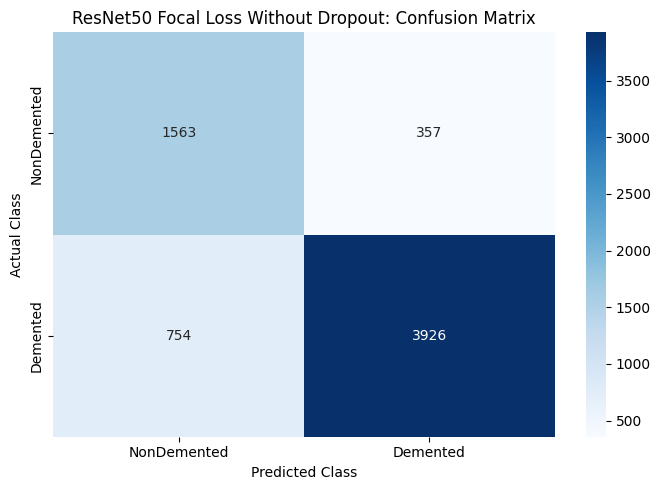

In [18]:
cm = confusion_matrix(true_labels, test_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"]
)

plt.title("ResNet50 Focal Loss Without Dropout: Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        test_predictions,
        target_names=["NonDemented", "Demented"],
        digits=4
    )
)

              precision    recall  f1-score   support

 NonDemented     0.6746    0.8141    0.7378      1920
    Demented     0.9166    0.8389    0.8760      4680

    accuracy                         0.8317      6600
   macro avg     0.7956    0.8265    0.8069      6600
weighted avg     0.8462    0.8317    0.8358      6600



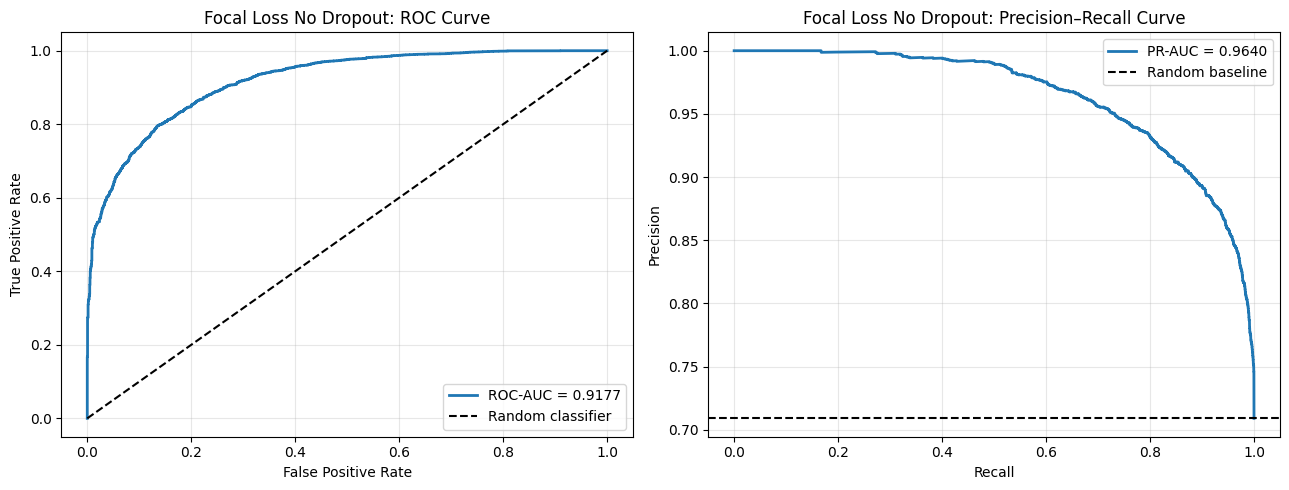

In [20]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(true_labels, test_probabilities)
pr_precision, pr_recall, _ = precision_recall_curve(
    true_labels, test_probabilities
)

roc_auc = roc_auc_score(true_labels, test_probabilities)
pr_auc = average_precision_score(true_labels, test_probabilities)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    fpr, tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.4f}"
)
axes[0].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[0].set_title("Focal Loss No Dropout: ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    pr_recall, pr_precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.4f}"
)
axes[1].axhline(
    true_labels.mean(),
    color="black",
    linestyle="--", 
    label="Random baseline"
)
axes[1].set_title("Focal Loss No Dropout: Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

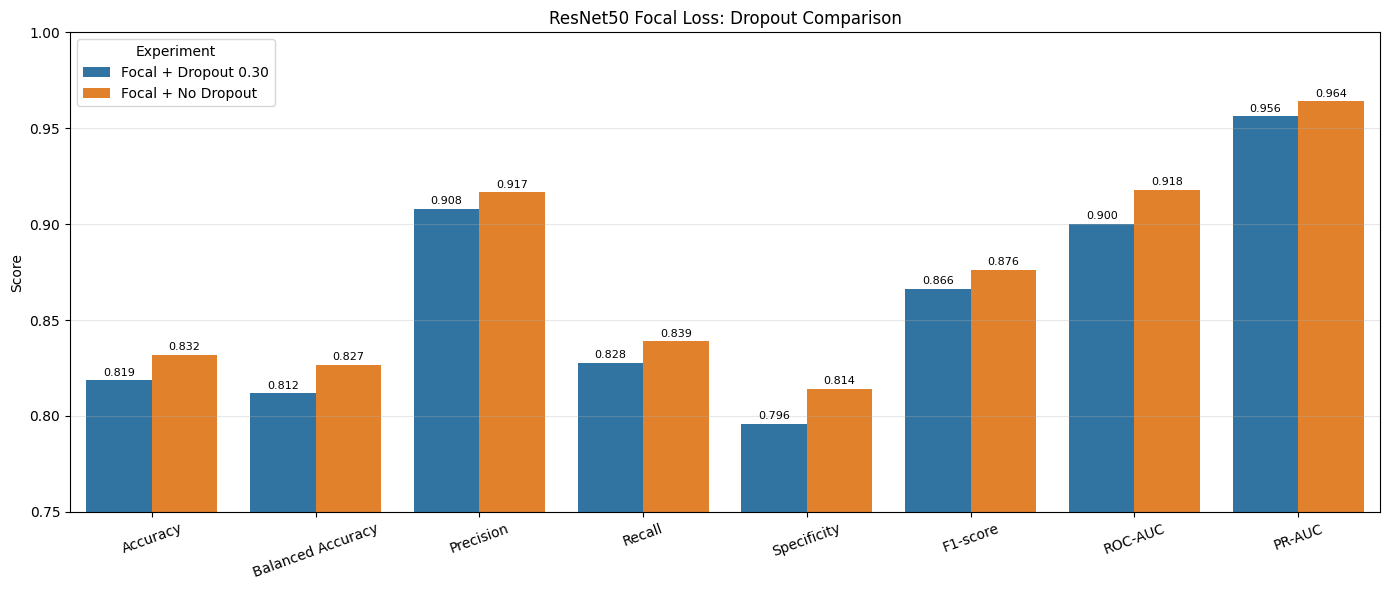

In [21]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy", "Balanced Accuracy", "Precision",
        "Recall", "Specificity", "F1-score",
        "ROC-AUC", "PR-AUC"
    ],
    "Focal + Dropout 0.30": [
        0.8185, 0.8118, 0.9081, 0.8278,
        0.7958, 0.8661, 0.9002, 0.9562
    ],
    "Focal + No Dropout": [
        0.8317, 0.8265, 0.9166, 0.8389,
        0.8141, 0.8760, 0.9177, 0.9640
    ]
})

plot_data = comparison.melt(
    id_vars="Metric",
    var_name="Experiment",
    value_name="Score"
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=plot_data,
    x="Metric",
    y="Score",
    hue="Experiment"
)

plt.ylim(0.75, 1.0)
plt.title("ResNet50 Focal Loss: Dropout Comparison")
plt.xlabel("")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
results = pd.DataFrame([{
    "Experiment": "ResNet50 Focal Loss No Dropout",
    "Focal Alpha": FOCAL_ALPHA,
    "Focal Gamma": FOCAL_GAMMA,
    "Test Focal Loss": test_loss,
    "Accuracy": accuracy_score(true_labels, test_predictions),
    "Balanced Accuracy": balanced_accuracy_score(
        true_labels, test_predictions
    ),
    "Precision": precision_score(true_labels, test_predictions),
    "Recall": recall_score(true_labels, test_predictions),
    "Specificity": specificity,
    "F1-score": f1_score(true_labels, test_predictions),
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}])

results.to_csv(
    "/kaggle/working/resnet50_focal_no_dropout_results.csv",
    index=False
)

pd.DataFrame(history.history).to_csv(
    "/kaggle/working/resnet50_focal_no_dropout_history.csv",
    index=False
)

prediction_results = test_df.copy()
prediction_results["probability"] = test_probabilities
prediction_results["prediction"] = test_predictions
prediction_results.to_csv(
    "/kaggle/working/resnet50_focal_no_dropout_predictions.csv",
    index=False
)

comparison.to_csv(
    "/kaggle/working/focal_dropout_comparison.csv",
    index=False
)

display(results)
print("All focal-loss no-dropout files saved.")

,Experiment,Focal Alpha,Focal Gamma,Test Focal Loss,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC
0,ResNet50 Focal Loss No Dropout,0.29,2.0,0.03891,0.831667,0.826476,0.916647,0.838889,0.814063,0.876046,0.917674,0.964016


All focal-loss no-dropout files saved.
